# mAP rank changes across compounds pre- vs post-QC

Uses the per-compound/dose mAP scores and cell-count/MoA summary computed in `../figure_5/5.calculate_mAP.ipynb` (`../figure_5/mAP_results/merged_map_preQC_postQC.parquet` and `../figure_5/mAP_results/compound_dose_cell_counts_moa.parquet`) to rank compounds within each dose (1-6) by mAP score and visualize how those ranks shift after applying single-cell QC.


In [1]:
import hashlib
import pathlib

import numpy as np
import pandas as pd
from plotnine import (
    aes,
    element_blank,
    element_text,
    facet_wrap,
    geom_bar,
    geom_hline,
    geom_line,
    geom_point,
    ggplot,
    labs,
    scale_color_gradientn,
    scale_fill_manual,
    scale_x_continuous,
    scale_y_reverse,
    theme,
    theme_bw,
)
from plotnine.options import set_option


## Helper functions


In [2]:
def dense_rank_by_score(df: pd.DataFrame, score_col: str) -> pd.Series:
    """Dense rank on mAP score alone, descending (1 = best); ties share a rank.

    mAP alone leaves large tie blocks (many compounds can share the same
    score, including a perfect score), so unlike a composite tie-break this
    intentionally leaves those ties in place rather than resolving them with
    auxiliary columns (p-value, cell count).

    Args:
        df (pd.DataFrame): DataFrame to rank (already restricted to one dose).
        score_col (str): Column to rank on, descending (e.g. mAP score).

    Returns:
        pd.Series: Dense rank (1 = best), aligned to df's index.
    """
    return df[score_col].rank(method="dense", ascending=False).astype(int)


def get_color(r: pd.Series) -> str:
    """Return the bar color for a rank_change row based on rank_diff sign.

    Args:
        r (pd.Series): A row of the rank_change DataFrame containing "rank_diff".

    Returns:
        str: "blue" if rank improved (rank_diff > 0), otherwise "red".
    """
    return "blue" if r["rank_diff"] > 0 else "red"


## Load mAP results and cell-count/MoA summary from figure_5


In [3]:
# Output paths for this supplementary figure
output_dir = pathlib.Path("./mAP_results")
output_dir.mkdir(parents=True, exist_ok=True)

figures_dir = pathlib.Path("./figures")
figures_dir.mkdir(parents=True, exist_ok=True)

# mAP results (doses 1-6, pre- and post-QC), computed in
# ../figure_5/5.calculate_mAP.ipynb
merged_map = pd.read_parquet("../figure_5/mAP_results/merged_map_preQC_postQC.parquet")

# Per compound/dose cell counts and MoA annotations, computed in
# ../figure_5/5.calculate_mAP.ipynb
compound_dose_summary = pd.read_parquet(
    "../figure_5/mAP_results/compound_dose_cell_counts_moa.parquet"
)

preqc_cell_counts = compound_dose_summary[
    ["Metadata_broad_sample", "Metadata_dose_recode", "total_cells_preQC"]
]
postqc_cell_counts = compound_dose_summary[
    ["Metadata_broad_sample", "Metadata_dose_recode", "total_passed_postQC"]
]
moa_info = compound_dose_summary[
    ["Metadata_broad_sample", "Metadata_moa"]
].drop_duplicates()

# Define the custom coSMic QC palette (lighter pink to purple to cyan)
cosmicqc_palette = [
    "#f8b3d3",  # Light pink
    "#ff5ca7",  # Vibrant pink
    "#8f30c9",  # Medium purple
    "#3b0085",  # Deep purple
    "#00cafd",  # Cyan accent
]

set_option("figure_size", (14, 4))


(6.4, 4.8)

## Plot mAP ranks


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-IJJSYAd6-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 14 x 4 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-IJJSYAd6-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/rank_mAP_preQC_vs_postQC_by_dose.png


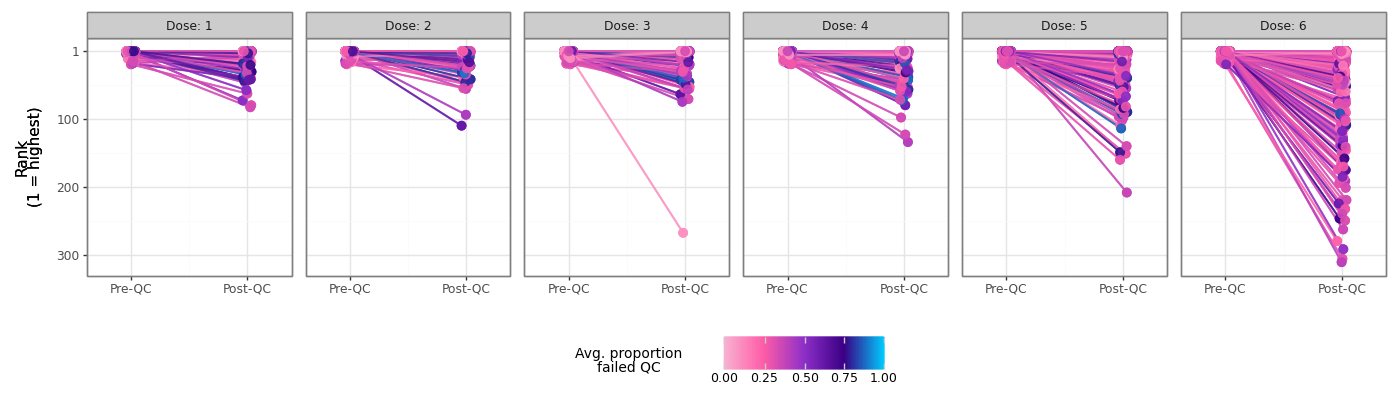

Number of compounds with preQC rank <= 20, per dose:
 {1: 132, 2: 163, 3: 232, 4: 285, 5: 302, 6: 553}


In [4]:
# Establish a deterministic row order so that any downstream tie-breaking
# is reproducible across reruns (pandas sort_values() is not stable by default)
merged_map_sorted = merged_map.sort_values(
    ["Metadata_dose_recode", "Metadata_broad_sample"]
).reset_index(drop=True)

# Attach the single-cell counts loaded above
merged_map_sorted = merged_map_sorted.merge(
    preqc_cell_counts, on=["Metadata_broad_sample", "Metadata_dose_recode"], how="left"
)
merged_map_sorted = merged_map_sorted.merge(
    postqc_cell_counts, on=["Metadata_broad_sample", "Metadata_dose_recode"], how="left"
)

# Rank independently within each dose, on mAP score alone (see
# dense_rank_by_score in the Helper functions section above). Ties (compounds
# sharing the same mAP score) are left in place rather than broken by
# auxiliary columns, so multiple compounds can share the same rank number -
# including rank 1.
merged_map_sorted["postQC_rank"] = merged_map_sorted.groupby(
    "Metadata_dose_recode", group_keys=False
).apply(
    lambda d: dense_rank_by_score(d, "mean_average_precision_postQC"),
    include_groups=False,
)
merged_map_sorted["preQC_rank"] = merged_map_sorted.groupby(
    "Metadata_dose_recode", group_keys=False
).apply(
    lambda d: dense_rank_by_score(d, "mean_average_precision_preQC"),
    include_groups=False,
)

# Keep ALL compounds whose preQC_rank falls within the top 20 rank values
# (not a fixed row count). Because ranks are dense and ties are common,
# this can include more than 20 compounds if many share ranks 1-20 - that's
# the correct, non-arbitrary definition of "top 20 ranked" under ties.
merged_map_top = merged_map_sorted[
    merged_map_sorted["preQC_rank"] <= 20
].copy()

# Reshape to long format so each compound has one row for preQC and one row
# for postQC, with a "QC_status" column as the x-axis of the slope chart,
# and a matching "rank" column as the y-axis.
long_pre = merged_map_top[
    [
        "Metadata_dose_recode",
        "Metadata_broad_sample",
        "preQC_rank",
        "Metadata_avg_prop_failed_single_cells_postQC",
    ]
].rename(columns={"preQC_rank": "rank"})
long_pre["QC_status"] = "Pre-QC"
long_pre["x_num"] = 0.0

long_post = merged_map_top[
    [
        "Metadata_dose_recode",
        "Metadata_broad_sample",
        "postQC_rank",
        "Metadata_avg_prop_failed_single_cells_postQC",
    ]
].rename(columns={"postQC_rank": "rank"})
long_post["QC_status"] = "Post-QC"
long_post["x_num"] = 1.0

merged_map_long = pd.concat([long_pre, long_post], ignore_index=True)
merged_map_long["QC_status"] = pd.Categorical(
    merged_map_long["QC_status"], categories=["Pre-QC", "Post-QC"], ordered=True
)

# Add a small, deterministic horizontal jitter within each QC_status column
# (not across it) so that compounds tied at the same rank fan out slightly
# instead of drawing one line directly on top of another. Jitter amount is
# derived from a hash of the compound ID so it's reproducible across reruns,
# and is kept small enough that lines still clearly start/end at their
# correct rank value.
def _deterministic_jitter(sample_id, scale=0.04):
    h = int(hashlib.md5(sample_id.encode()).hexdigest(), 16)
    return ((h % 1000) / 1000 - 0.5) * 2 * scale

merged_map_long["jitter"] = merged_map_long["Metadata_broad_sample"].apply(
    _deterministic_jitter
)
merged_map_long["x_jittered"] = merged_map_long["x_num"] + merged_map_long["jitter"]

# Slope chart: one line per compound connecting its preQC rank to its
# postQC rank, colored by average proportion of cells that failed QC.
# y-axis is reversed so rank 1 (best) is at the top, matching how ranks
# are usually read. Because "top 20 ranked" can include more compounds than
# 20 under ties, the title reports the actual compound count per dose via
# the caption below rather than assuming exactly 20.
n_compounds_per_dose = (
    merged_map_top.groupby("Metadata_dose_recode")["Metadata_broad_sample"]
    .nunique()
    .to_dict()
)

# Explicit y-axis bounds so the reversed scale starts at rank 1 (top) and
# ends at the true max rank present in the plotted data (bottom), rather
# than plotnine's default expansion pulling the axis down toward/through 0.
max_rank = int(merged_map_long["rank"].max())

# Round-number breaks like before (100, 200, 300...), but swap the leading
# 0 for 1 so the top of the axis is labeled correctly
y_breaks = [1] + list(range(100, max_rank + 1, 100))

p = (
    ggplot(
        merged_map_long,
        aes(
            x="x_jittered",
            y="rank",
            group="Metadata_broad_sample",
            color="Metadata_avg_prop_failed_single_cells_postQC",
        ),
    )
    + geom_line(alpha=0.7, size=0.8)
    + geom_point(size=3, alpha=0.9)
    + scale_color_gradientn(
        name="Avg. proportion\nfailed QC",
        colors=cosmicqc_palette,
        limits=(0, 1),
    )
    + scale_x_continuous(
        breaks=[0, 1],
        labels=["Pre-QC", "Post-QC"],
        name="",
        limits=(-0.3, 1.3),
    )
    + scale_y_reverse(
        name="Rank\n(1 = highest)",
        limits=(max_rank, 1),
        breaks=y_breaks,
        expand=(0, 20),
    )
    + facet_wrap(
        "~Metadata_dose_recode",
        nrow=1,
        labeller=lambda x: f"Dose: {x}",
    )
    + theme_bw()
    + theme(
        figure_size=(14, 4),
        legend_position="bottom",
        legend_title=element_text(size=10),
        legend_text=element_text(size=9),
    )
)

# Save plots
p.save("figures/rank_mAP_preQC_vs_postQC_by_dose.png", dpi=400)
fig = p.draw()

for ax in fig.axes:
    for coll in ax.collections:
        coll.set_rasterized(True)

fig.savefig("figures/rank_mAP_preQC_vs_postQC_by_dose.svg", dpi=400)

p.show()

print(
    "Number of compounds with preQC rank <= 20, per dose:\n",
    n_compounds_per_dose,
)


In [5]:
# Compounds that moved from OUTSIDE the top 20 pre-QC (preQC_rank > 20) into
# the top 20 post-QC (postQC_rank <= 20). This is computed directly off the
# full per-dose rank columns (not the nsmallest(20, ...) cut used for
# merged_map_top/rank_change below), since under plain mAP ranking many
# compounds can be tied at a given rank number and nsmallest would only keep
# an arbitrary subset of a tied group - checking the rank *value* against the
# threshold instead captures every compound that actually crossed into
# postQC_rank <= 20, tied or not.
moved_into_top20 = merged_map_sorted.loc[
    (merged_map_sorted["preQC_rank"] > 20)  # noqa: PLR2004
    & (merged_map_sorted["postQC_rank"] <= 20)  # noqa: PLR2004
].sort_values(["Metadata_dose_recode", "postQC_rank"])

print(
    f"{len(moved_into_top20)} compound/dose entries moved from outside the "
    "top 20 pre-QC into the top 20 post-QC, across "
    f"{moved_into_top20['Metadata_broad_sample'].nunique()} unique compounds:"
)
moved_into_top20[
    [
        "Metadata_broad_sample",
        "Metadata_dose_recode",
        "preQC_rank",
        "postQC_rank",
        "mean_average_precision_preQC",
        "mean_average_precision_postQC",
    ]
]


50 compound/dose entries moved from outside the top 20 pre-QC into the top 20 post-QC, across 46 unique compounds:


,Metadata_broad_sample,Metadata_dose_recode,preQC_rank,postQC_rank,mean_average_precision_preQC,mean_average_precision_postQC
381,BRD-K03194791-001-04-8,1,23,1,0.910714,1.000000
144,BRD-A36331462-001-02-1,1,22,2,0.910833,0.990000
410,BRD-K06240250-001-01-6,1,52,8,0.805141,0.960833
1298,BRD-K79095980-001-09-6,1,36,11,0.862222,0.956667
1255,BRD-K75295174-001-05-0,1,29,12,0.885278,0.951905
1123,BRD-K64990520-001-08-4,1,31,13,0.881160,0.950794
616,BRD-K23204545-001-16-4,1,25,18,0.908440,0.939405
495,BRD-K13662825-001-07-5,1,35,20,0.863095,0.936429
2038,BRD-K12787259-001-04-3,2,22,1,0.910317,1.000000
2748,BRD-K70511574-001-06-9,2,27,9,0.898566,0.967500


In [6]:
# Compounds that moved from INSIDE the top 20 pre-QC (preQC_rank <= 20) to
# OUTSIDE the top 20 post-QC (postQC_rank > 20) - the mirror image of
# moved_into_top20 above: treatments whose pre-QC profile ranked well but
# dropped out of the top 20 once cell-level QC was applied.
left_top20_postQC = merged_map_sorted.loc[
    (merged_map_sorted["preQC_rank"] <= 20)  # noqa: PLR2004
    & (merged_map_sorted["postQC_rank"] > 20)  # noqa: PLR2004
].sort_values(["Metadata_dose_recode", "preQC_rank"])

print(
    f"{len(left_top20_postQC)} compound/dose entries moved from the top 20 "
    "pre-QC to outside the top 20 post-QC, across "
    f"{left_top20_postQC['Metadata_broad_sample'].nunique()} unique compounds:"
)
left_top20_postQC[
    [
        "Metadata_broad_sample",
        "Metadata_dose_recode",
        "preQC_rank",
        "postQC_rank",
        "mean_average_precision_preQC",
        "mean_average_precision_postQC",
    ]
]


271 compound/dose entries moved from the top 20 pre-QC to outside the top 20 post-QC, across 187 unique compounds:


,Metadata_broad_sample,Metadata_dose_recode,preQC_rank,postQC_rank,mean_average_precision_preQC,mean_average_precision_postQC
234,BRD-A66419424-001-02-4,1,1,73,1.000000,0.724104
454,BRD-K09426783-300-01-0,1,1,39,1.000000,0.890238
589,BRD-K20958582-001-01-4,1,1,26,1.000000,0.913056
898,BRD-K47869605-001-32-0,1,1,31,1.000000,0.905556
968,BRD-K53417444-003-03-1,1,1,44,1.000000,0.864848
...,...,...,...,...,...,...
8520,BRD-K34776109-001-16-6,6,15,26,0.958571,0.951905
9149,BRD-K86816506-001-01-8,6,15,49,0.958571,0.931905
8429,BRD-K28143534-003-25-9,6,17,72,0.957500,0.909167
7949,BRD-A50675702-001-07-1,6,19,305,0.956667,0.650404


In [7]:
# Export the compound/dose pairs that were top-20 pre-QC but left the top 20
# post-QC, for use in downstream notebooks (mirrors the rescued-compound
# export below)
left_top20_postQC[["Metadata_broad_sample", "Metadata_dose_recode"]].to_csv(
    output_dir / "left_top20_all_doses.csv", index=False
)


# Sort by ranks pre- and post-QC


In [8]:
# Print for dose recode 4 the sample, ranks, mAP scores, p-values, and cell
# counts pre and post QC
merged_map_sorted.loc[
    merged_map_sorted["Metadata_dose_recode"] == 4,  # noqa: PLR2004
    [
        "Metadata_broad_sample",
        "preQC_rank",
        "postQC_rank",
        "mean_average_precision_preQC",
        "mean_average_precision_postQC",
        "mAP_change",
        "corrected_p_value_preQC",
        "corrected_p_value_postQC",
        "total_cells_preQC",
        "total_passed_postQC",
    ],
].sort_values("postQC_rank").head(10)


,Metadata_broad_sample,preQC_rank,postQC_rank,mean_average_precision_preQC,mean_average_precision_postQC,mAP_change,corrected_p_value_preQC,corrected_p_value_postQC,total_cells_preQC,total_passed_postQC
4687,BRD-A05821830-341-01-5,1,1,1.000,1.0,0.000,0.000338,0.000354,1236,299
6216,BRD-K99964838-001-11-9,1,1,1.000,1.0,0.000,0.000338,0.000354,12454,7848
5234,BRD-K19416115-001-05-3,1,1,1.000,1.0,0.000,0.000338,0.000354,1639,780
5239,BRD-K19540840-001-09-4,7,1,0.975,1.0,0.025,0.000338,0.000354,12645,8407
4715,BRD-A13133631-001-04-0,1,1,1.000,1.0,0.000,0.000338,0.000354,7877,5689
5211,BRD-K17743125-001-08-4,1,1,1.000,1.0,0.000,0.000338,0.000354,5648,2812
5215,BRD-K17944737-001-02-1,1,1,1.000,1.0,0.000,0.000338,0.000354,12132,8451
5217,BRD-K18157228-001-01-7,1,1,1.000,1.0,0.000,0.000338,0.000354,3131,1482
6212,BRD-K99545815-001-06-3,1,1,1.000,1.0,0.000,0.000338,0.000354,10292,9234
5219,BRD-K18324993-001-01-6,1,1,1.000,1.0,0.000,0.000338,0.000354,11920,10772


## Find the compounds in the top-20 ranking pre- and post-QC and find rescued compounds


In [9]:
# Step 1: Identify compounds within the top 20 RANK VALUES per dose (not a
# fixed row count). mAP has large tie blocks near the ceiling (e.g. hundreds
# of compounds can share rank 1 in a single dose), so nsmallest(20, ...)
# would just grab an arbitrary 20 rows out of that tie block and never
# reach rank 2+ at all. Filtering on the rank value instead (same approach
# as merged_map_top and moved_into_top20 above) keeps every compound tied
# within ranks 1-20, so a genuinely rescued compound (e.g. preQC_rank=43,
# postQC_rank=15) is actually captured here instead of being silently
# excluded by nsmallest's arbitrary tie-breaking.
top20_pre = merged_map_sorted.loc[
    merged_map_sorted["preQC_rank"] <= 20,
    ["Metadata_broad_sample", "Metadata_dose_recode", "preQC_rank"],
]

top20_post = merged_map_sorted.loc[
    merged_map_sorted["postQC_rank"] <= 20,
    ["Metadata_broad_sample", "Metadata_dose_recode", "postQC_rank"],
]

# Step 2: Union of compounds (per dose, either top-20 pre OR post)
rank_change = pd.merge(
    top20_pre,
    top20_post,
    on=["Metadata_broad_sample", "Metadata_dose_recode"],
    how="outer",
)

# Add back Metadata_moa (loaded above)
rank_change = rank_change.merge(
    moa_info, on="Metadata_broad_sample", how="left"
)

# Step 3: Attach full dataset ranks, mAP scores, p-values, and cell counts.
# merged_map_sorted has a rank for every compound (not just top-20 ones),
# so this left-merge overwrites the preQC_rank/postQC_rank columns from
# Step 1/2 with each compound's TRUE full-population rank - which is what
# we want, since rank_diff below should reflect real rank movement, not an
# artifact of the top-20 cut.
rank_change = pd.merge(
    rank_change,
    merged_map_sorted[
        [
            "Metadata_broad_sample",
            "Metadata_dose_recode",
            "preQC_rank",
            "postQC_rank",
            "mean_average_precision_preQC",
            "mean_average_precision_postQC",
            "mAP_change",
            "corrected_p_value_preQC",
            "corrected_p_value_postQC",
            "total_cells_preQC",
            "total_passed_postQC",
        ]
    ],
    on=["Metadata_broad_sample", "Metadata_dose_recode"],
    how="left",
    suffixes=("_top20", "")
)

# Enforce clean rank columns (avoid suffix confusion)
rank_change["preQC_rank"] = rank_change["preQC_rank"].fillna(rank_change["preQC_rank_top20"])
rank_change["postQC_rank"] = rank_change["postQC_rank"].fillna(rank_change["postQC_rank_top20"])

# Drop helper columns
rank_change = rank_change.drop(columns=[c for c in rank_change.columns if "_top20" in c])

# Step 4: Keep the UNION — a compound only needs to be top-20 for EITHER
# pre or post QC (per dose) to appear here. No dropna: dropping rows
# missing one rank would undo the whole point of the outer merge and hide
# compounds that entered/dropped out of a dose's top 20 due to QC.

# Step 5: Compute rank differences (pre - post → positive = improved).
# Both columns are always populated here (every compound in rank_change
# exists in merged_map_sorted, which has full-population ranks for
# everyone), so rank_diff is a genuine full-dataset rank comparison for
# every row - not restricted to the top-20 cut itself.
rank_change["rank_diff"] = rank_change["preQC_rank"] - rank_change["postQC_rank"]

# Step 6: Define color (no gray category; see get_color in the Helper
# functions section above)
rank_change["color"] = rank_change.apply(get_color, axis=1)

# Step 7: Order compounds per dose for plotting
rank_change["sort_rank"] = rank_change["preQC_rank"].fillna(rank_change["postQC_rank"])
rank_change = rank_change.sort_values(["Metadata_dose_recode", "sort_rank"])
print(rank_change.shape)

rank_change[
    [
        "Metadata_broad_sample",
        "Metadata_dose_recode",
        "preQC_rank",
        "postQC_rank",
        "rank_diff",
        "mean_average_precision_preQC",
        "mean_average_precision_postQC",
        "mAP_change",
        "corrected_p_value_preQC",
        "corrected_p_value_postQC",
        "total_cells_preQC",
        "total_passed_postQC",
    ]
].head(10)


(1717, 15)


,Metadata_broad_sample,Metadata_dose_recode,preQC_rank,postQC_rank,rank_diff,mean_average_precision_preQC,mean_average_precision_postQC,mAP_change,corrected_p_value_preQC,corrected_p_value_postQC,total_cells_preQC,total_passed_postQC
10,BRD-A05821830-341-01-5,1,1,1,0,1.0,1.00,0.00,0.000338,0.000354,1419,262
24,BRD-A11319535-001-03-6,1,1,1,0,1.0,1.00,0.00,0.000338,0.000354,9428,6460
44,BRD-A15435692-003-02-3,1,1,1,0,1.0,1.00,0.00,0.000338,0.000354,6280,5676
74,BRD-A26095496-001-04-0,1,1,1,0,1.0,1.00,0.00,0.000338,0.000354,11163,8200
95,BRD-A28746609-001-11-5,1,1,1,0,1.0,1.00,0.00,0.000338,0.000354,1340,481
106,BRD-A33280134-001-04-7,1,1,1,0,1.0,1.00,0.00,0.000338,0.000354,6903,6198
118,BRD-A36010170-001-04-0,1,1,1,0,1.0,1.00,0.00,0.000338,0.000354,7460,5249
124,BRD-A36057565-001-01-0,1,1,1,0,1.0,1.00,0.00,0.000338,0.000354,1430,1114
144,BRD-A43331270-001-01-6,1,1,2,-1,1.0,0.99,-0.01,0.000338,0.000354,9526,5855
150,BRD-A48237631-001-04-8,1,1,1,0,1.0,1.00,0.00,0.000338,0.000354,8338,4478


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-IJJSYAd6-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 14 x 6 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-IJJSYAd6-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/rank_change_dose_1_bar_plot.png


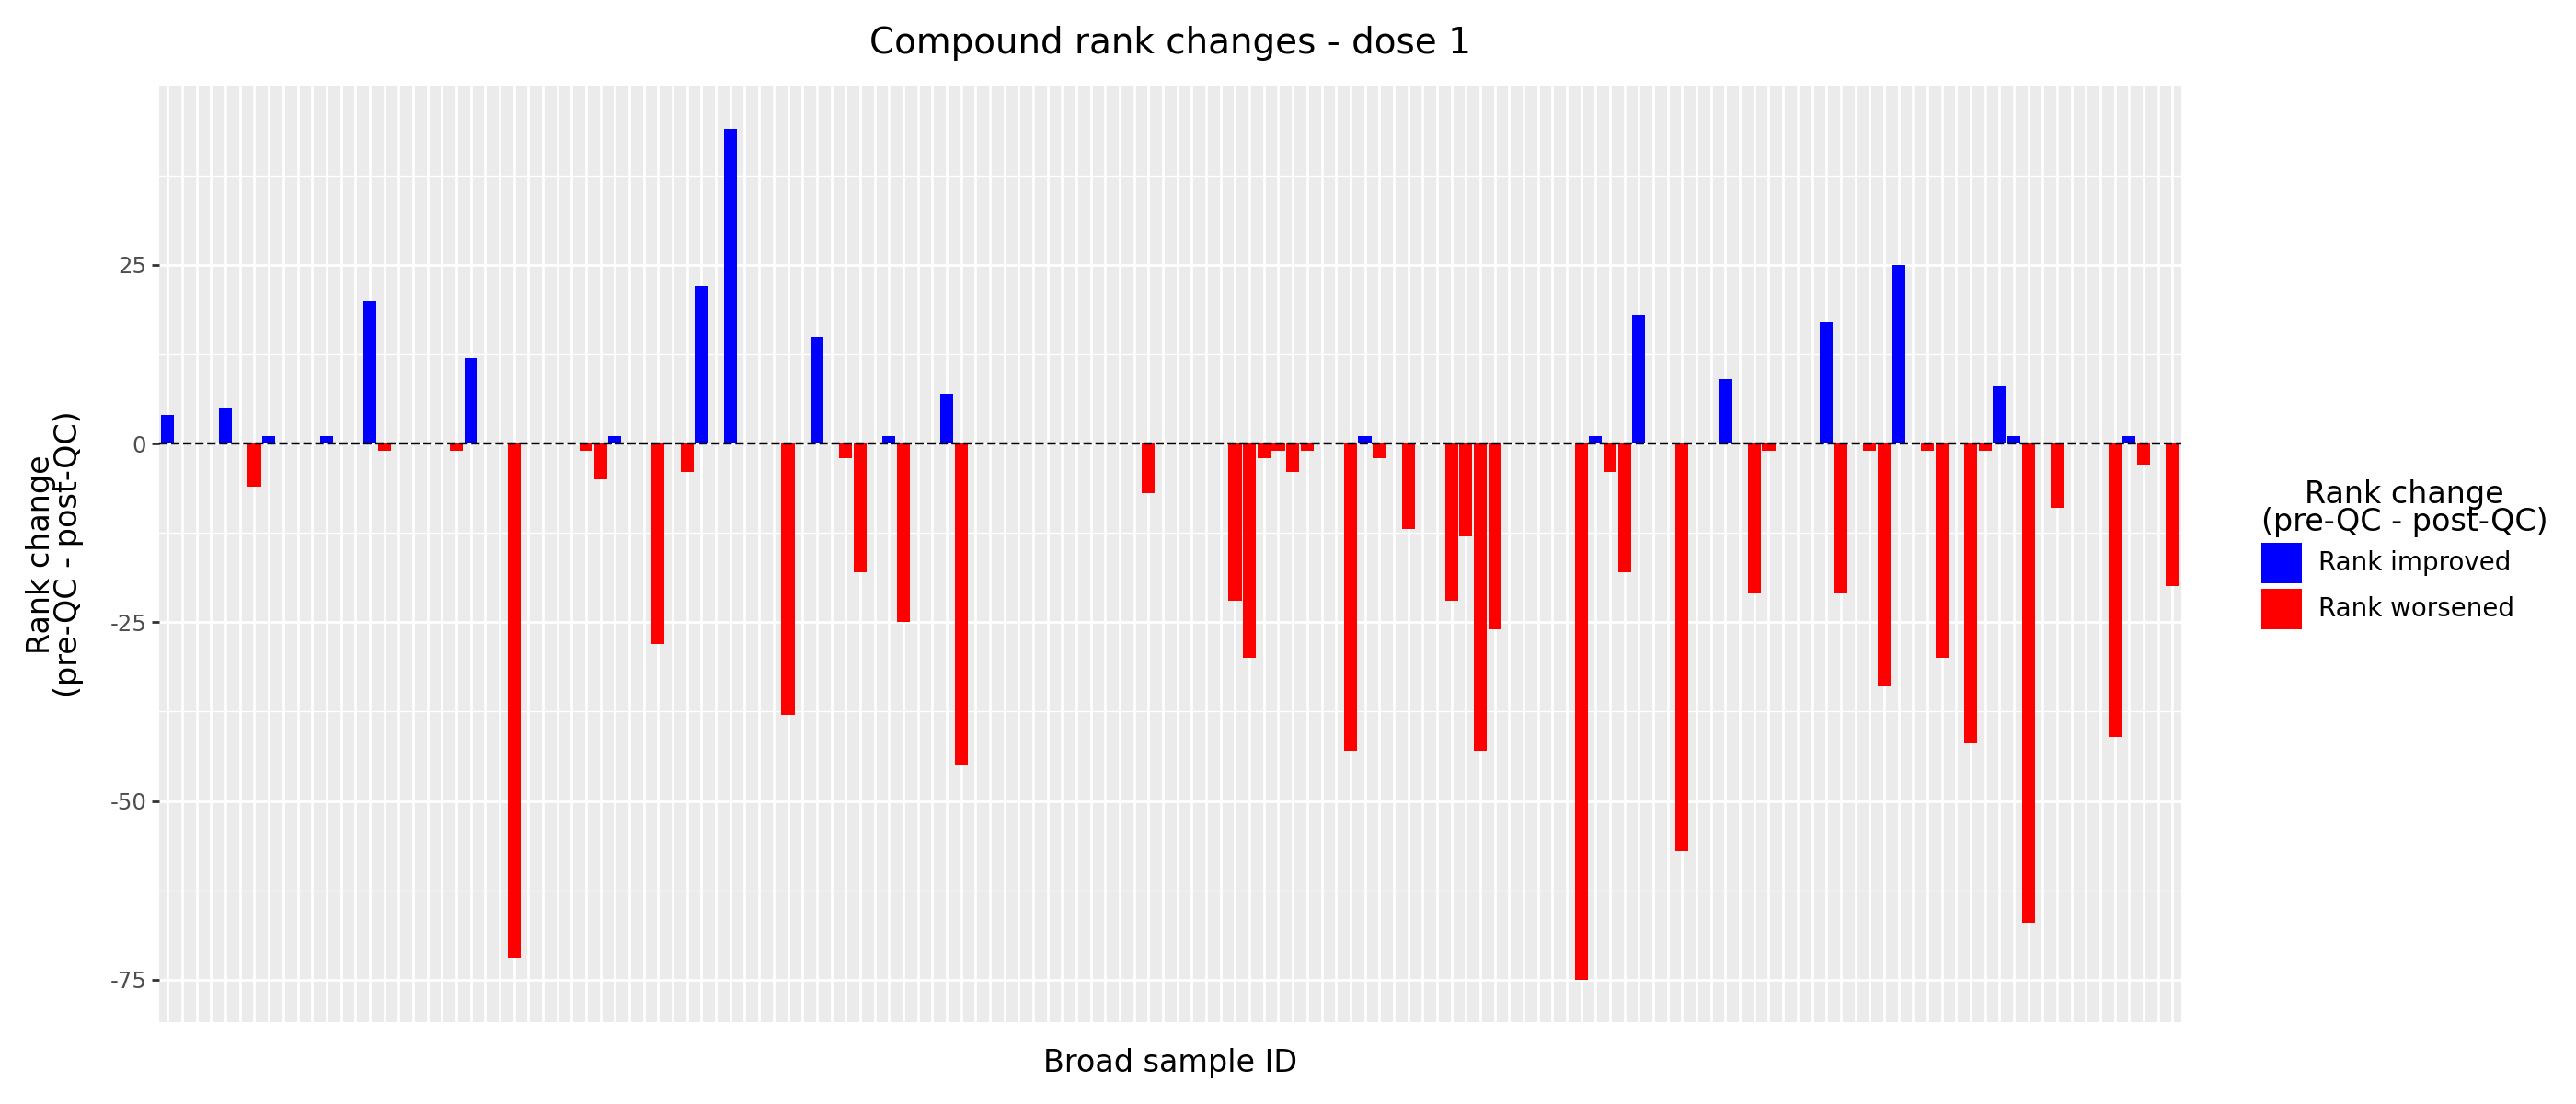

/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-IJJSYAd6-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 14 x 6 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-IJJSYAd6-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/rank_change_dose_2_bar_plot.png


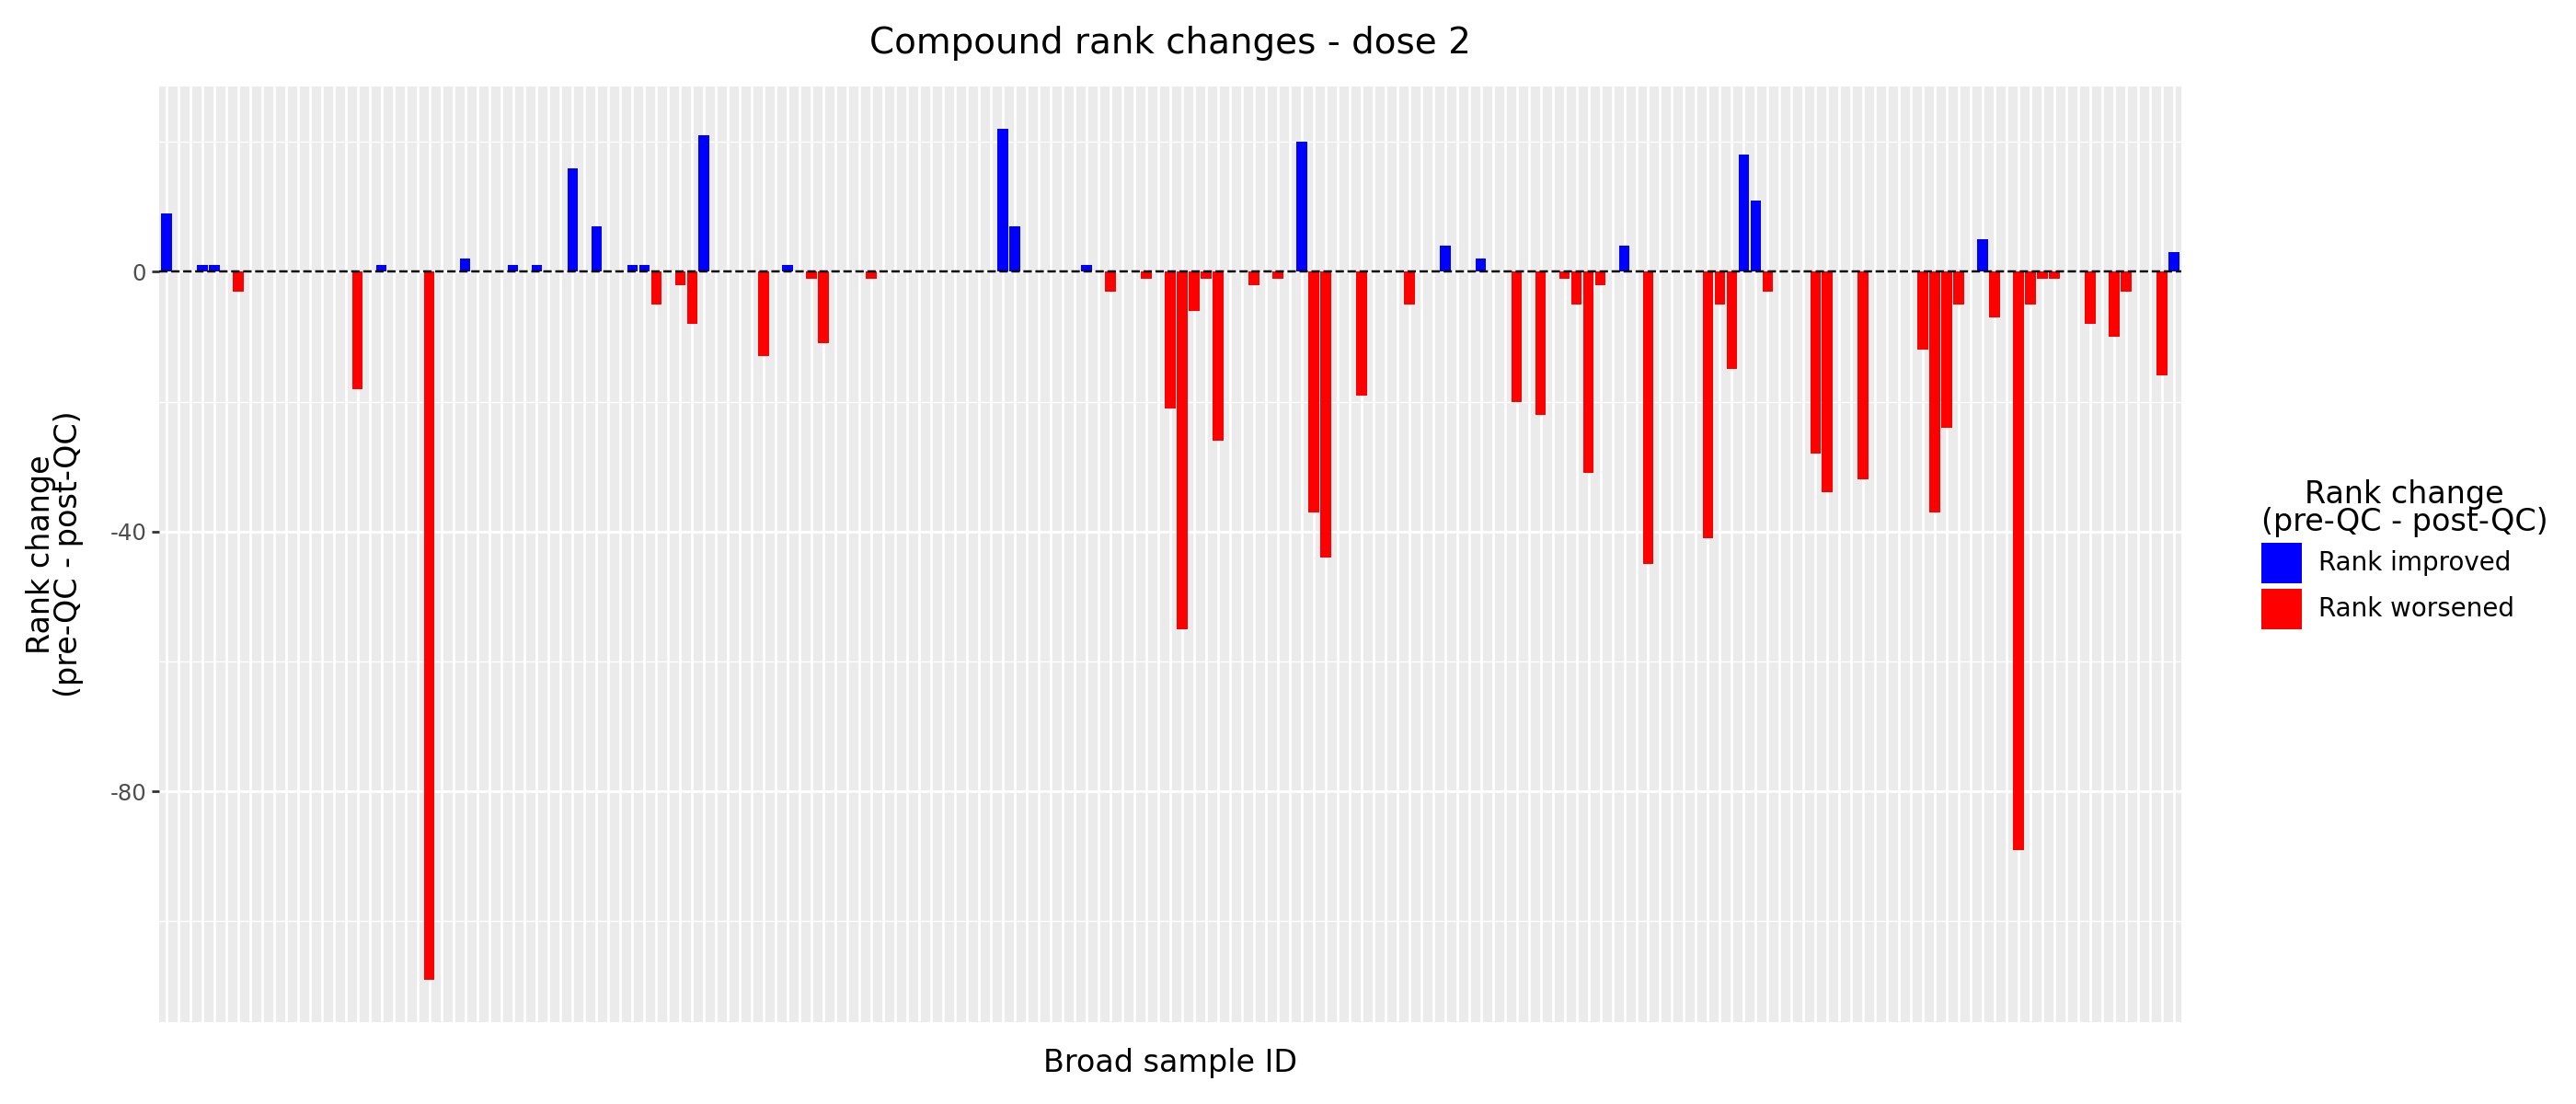

/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-IJJSYAd6-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 14 x 6 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-IJJSYAd6-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/rank_change_dose_3_bar_plot.png


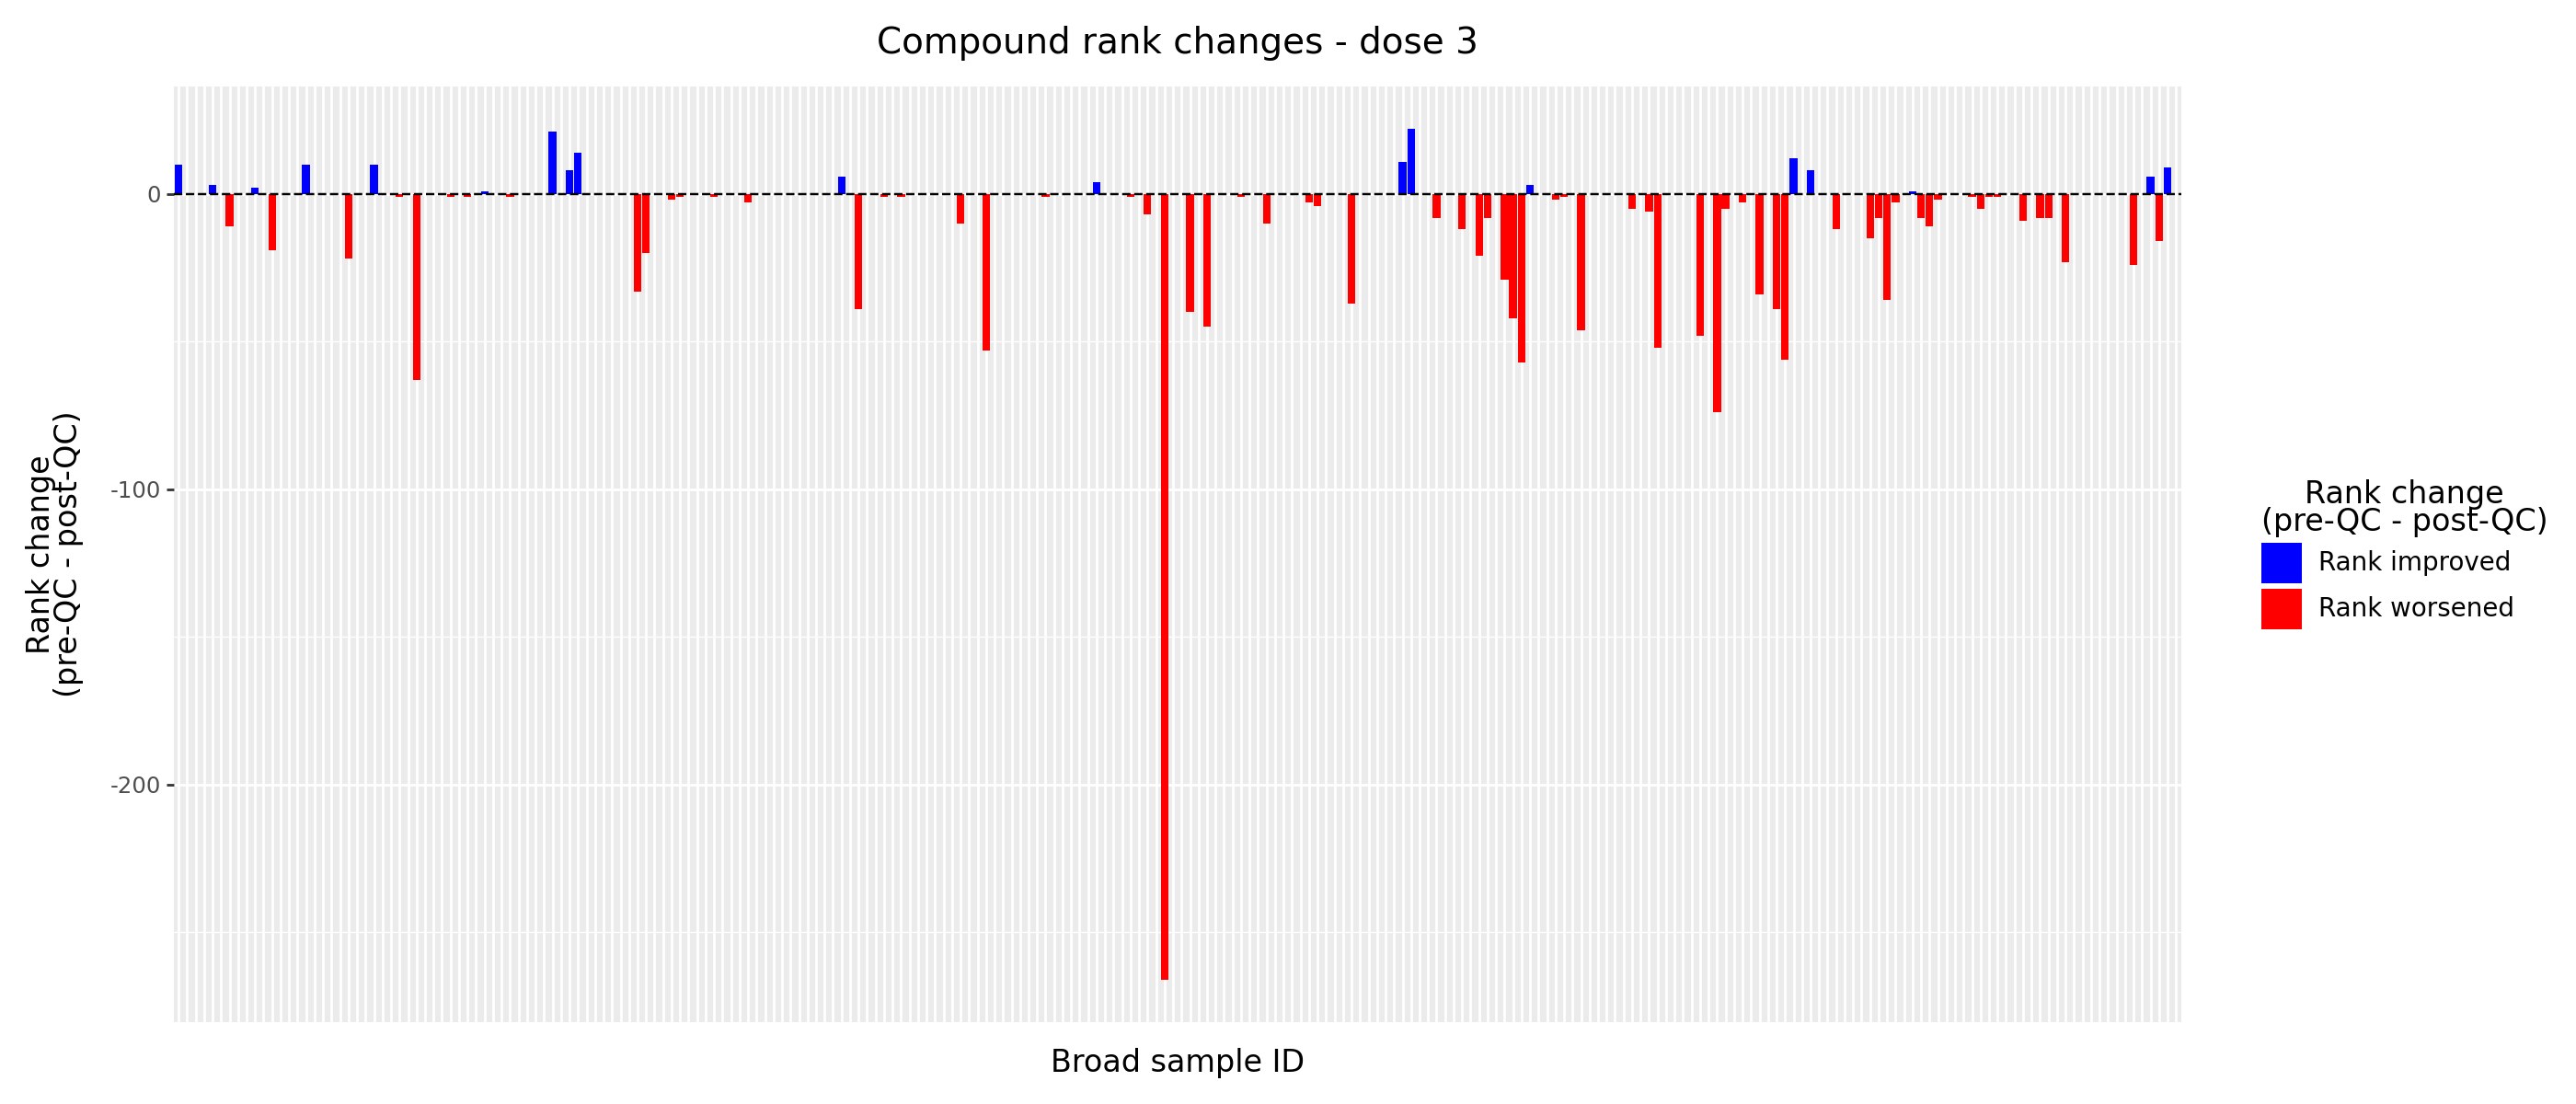

/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-IJJSYAd6-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 14 x 6 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-IJJSYAd6-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/rank_change_dose_4_bar_plot.png


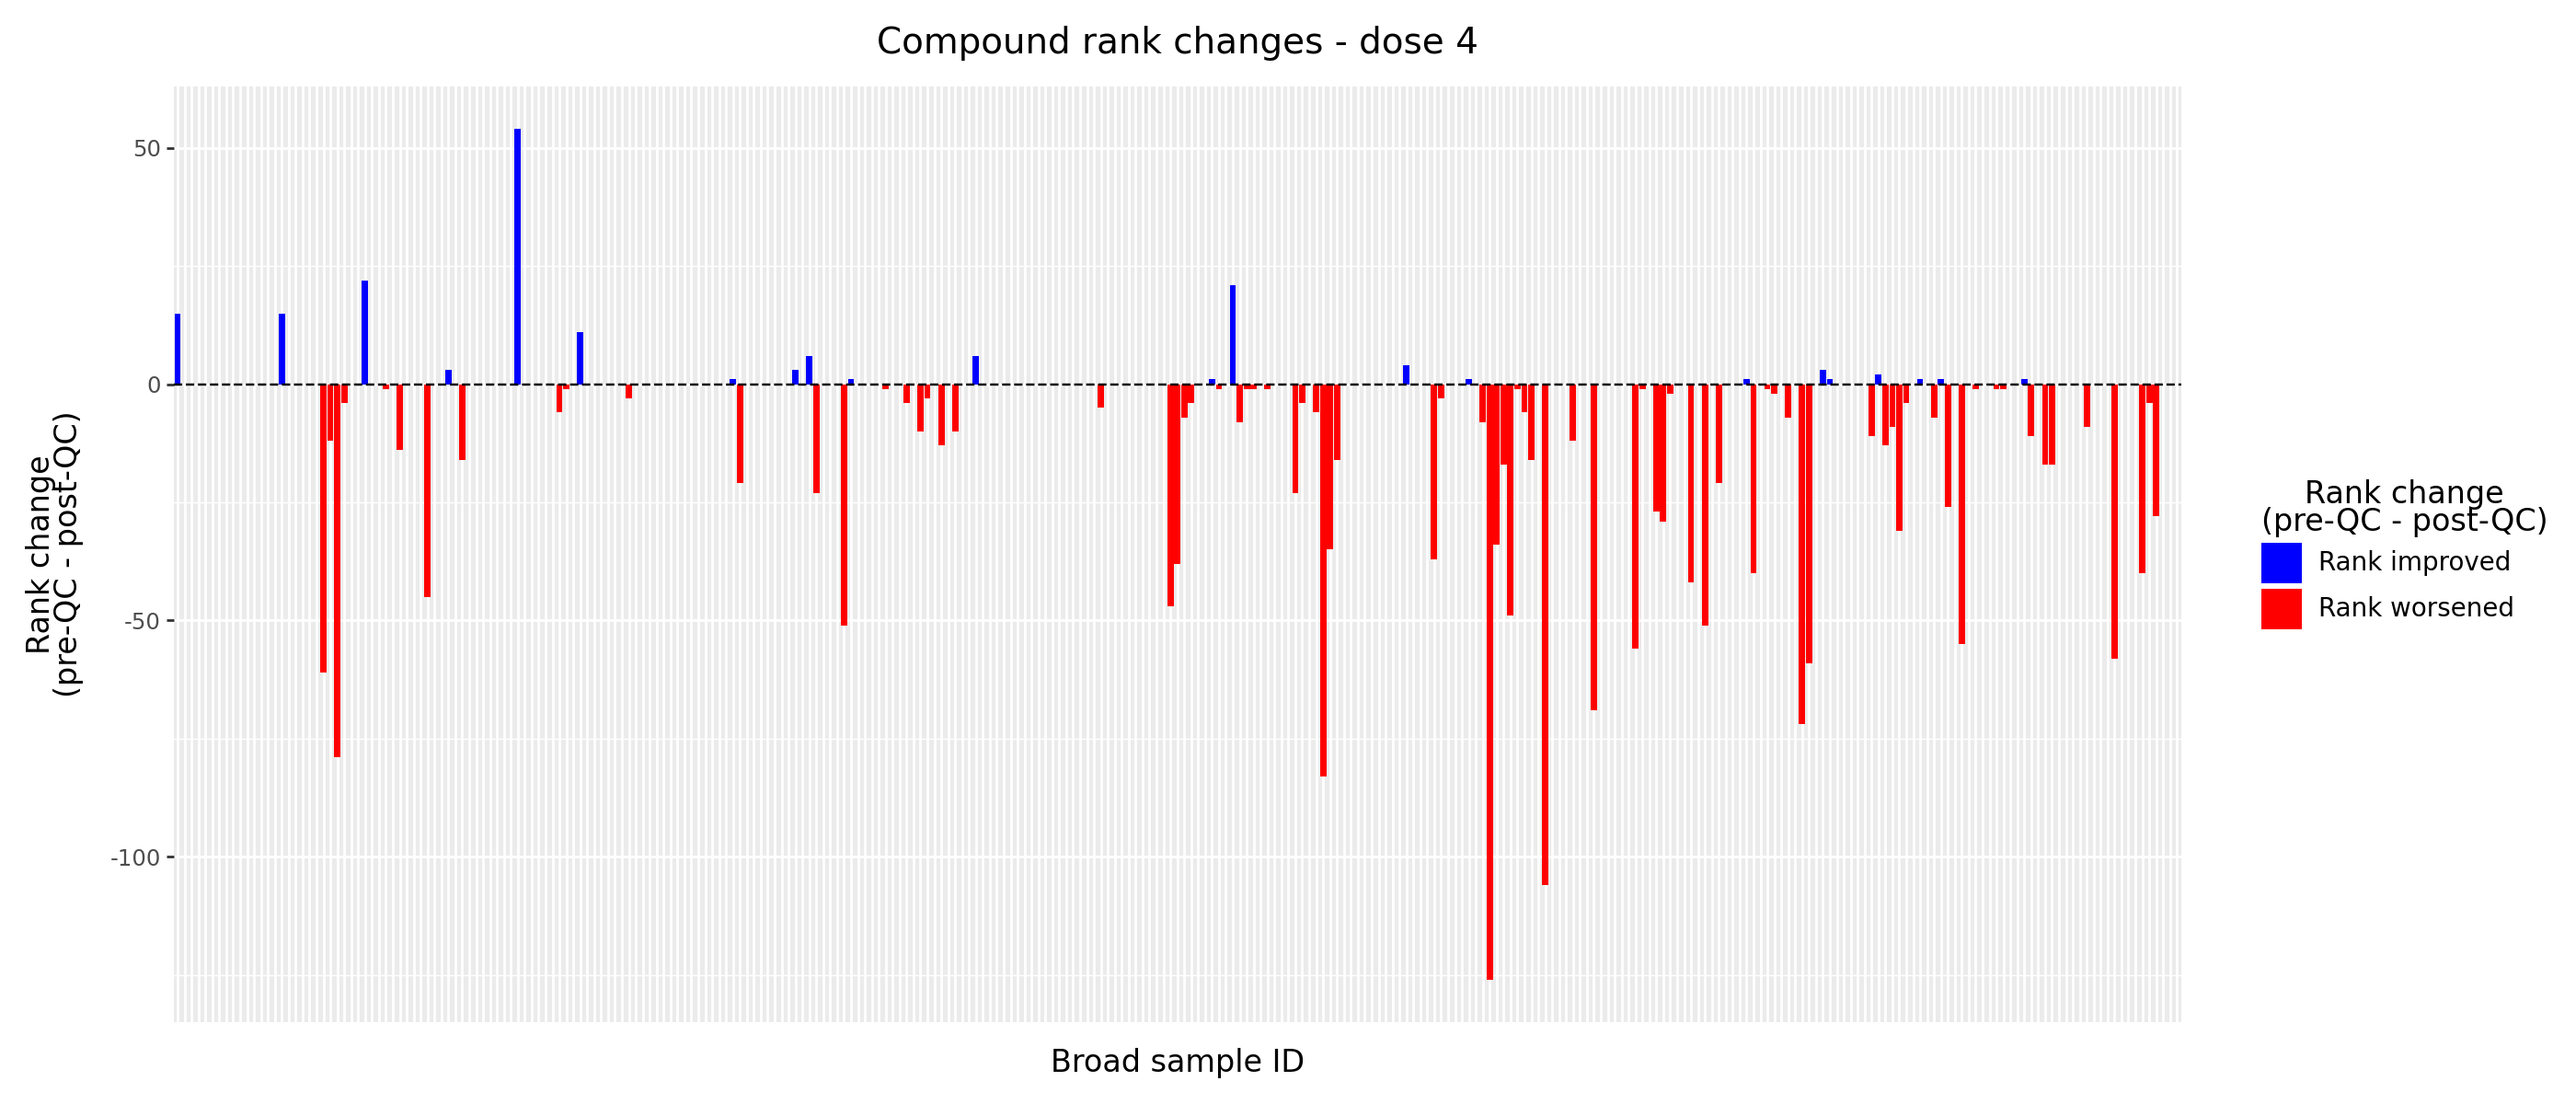

/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-IJJSYAd6-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 14 x 6 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-IJJSYAd6-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/rank_change_dose_5_bar_plot.png


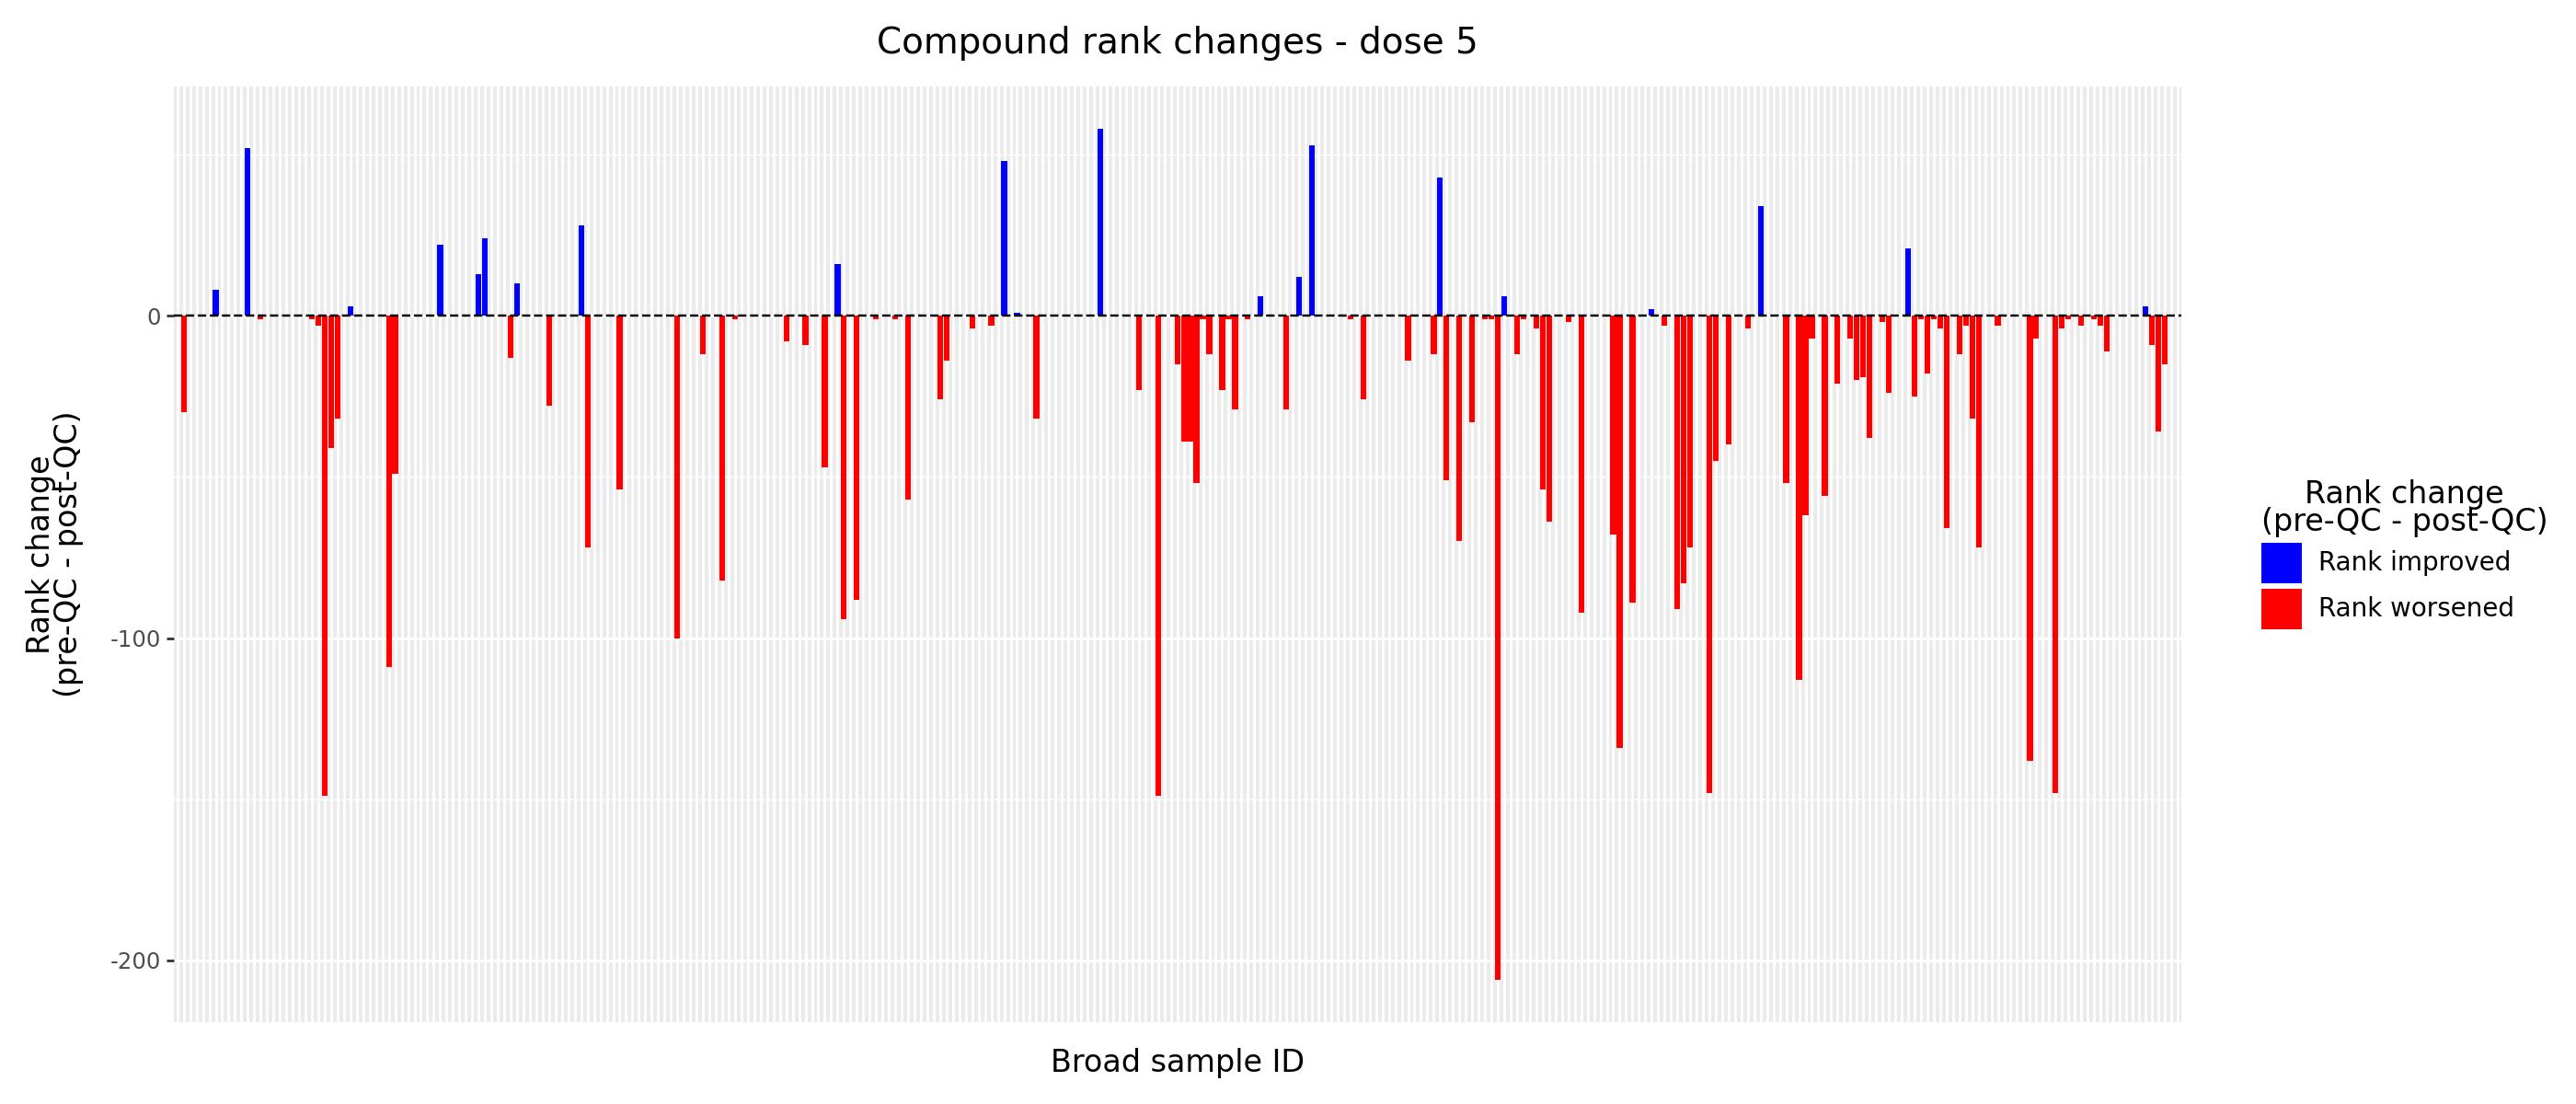

/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-IJJSYAd6-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 14 x 6 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-IJJSYAd6-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/rank_change_dose_6_bar_plot.png


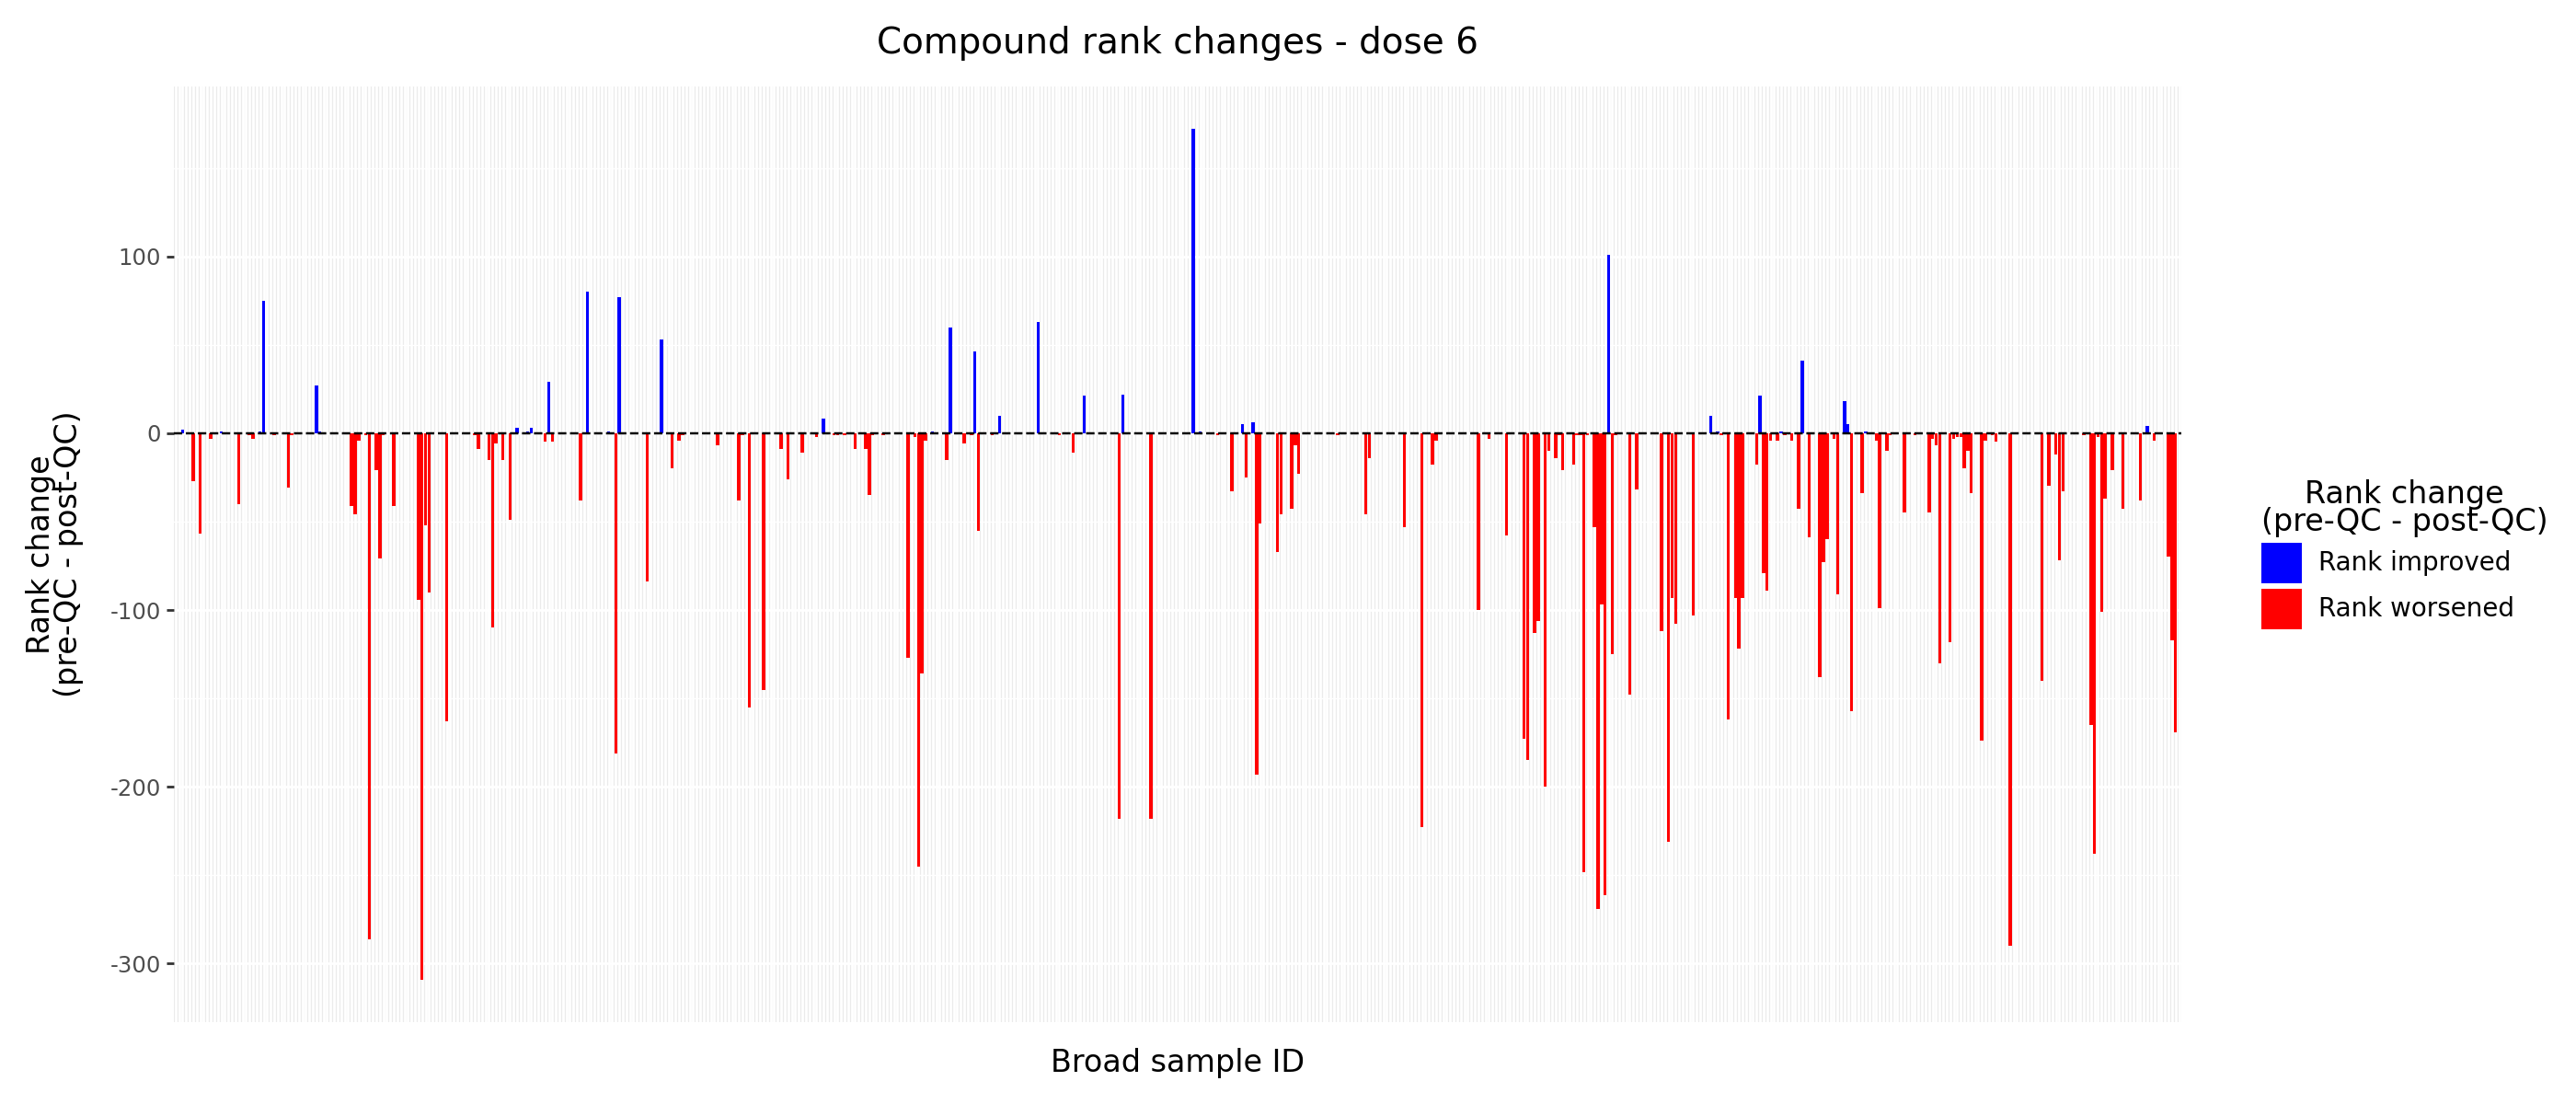

In [10]:
# Step 8: Plot per dose
for dose, df_dose in rank_change.groupby("Metadata_dose_recode"):

    if df_dose["rank_diff"].eq(0).all():
        continue

    p = (
        ggplot(df_dose, aes(x="Metadata_broad_sample", y="rank_diff", fill="color"))
        + geom_bar(stat="identity")
        + geom_hline(yintercept=0, color="black", linetype="dashed")
        + scale_fill_manual(
            name="Rank change\n(pre-QC - post-QC)",
            values={
                "blue": "blue",
                "red": "red"
            },
            labels=[
                "Rank improved",
                "Rank worsened"
            ],
        )
        + theme(
            figure_size=(14, 6),
            title=element_text(size=14),
            axis_text_x=element_blank(),
            axis_ticks_major_x=element_blank(),
            axis_title_x=element_text(size=12),
            axis_title_y=element_text(size=12),
            legend_title=element_text(size=12),
            legend_text=element_text(size=10),
        )
        + labs(
            title=f"Compound rank changes - dose {dose}",
            x="Broad sample ID",
            y="Rank change\n(pre-QC - post-QC)",
        )
    )

    plot_path = f"figures/rank_change_dose_{dose}_bar_plot.png"
    p.save(plot_path, width=14, height=6, dpi=600)
    p.show()


## Go over most rescued compounds


In [11]:
# Only include compounds that were NOT in the top 20 pre-QC and moved INTO
# the top 20 post-QC - i.e. genuinely rescued compounds, excluding compounds
# that were already in the top 20 pre-QC and simply moved to an even better
# rank (moved_into_top20 already only contains doses 1-6, since doses 0 and 7
# were dropped in ../figure_5/5.calculate_mAP.ipynb due to their small
# sample size)
improved_all_doses = moved_into_top20

# Only include broad sample and dose columns
improved_compounds = improved_all_doses[
    ["Metadata_broad_sample", "Metadata_dose_recode"]
]
broad_samples = improved_compounds["Metadata_broad_sample"].unique()

print(
    f"Broad samples of the {len(broad_samples)} unique compounds rescued into "
    "the top 20 post-QC (were outside the top 20 pre-QC), across doses (1-6):"
)
for sample in broad_samples:
    print(sample)


Broad samples of the 46 unique compounds rescued into the top 20 post-QC (were outside the top 20 pre-QC), across doses (1-6):
BRD-K03194791-001-04-8
BRD-A36331462-001-02-1
BRD-K06240250-001-01-6
BRD-K79095980-001-09-6
BRD-K75295174-001-05-0
BRD-K64990520-001-08-4
BRD-K23204545-001-16-4
BRD-K13662825-001-07-5
BRD-K12787259-001-04-3
BRD-K70511574-001-06-9
BRD-K53508936-001-01-0
BRD-K35719256-001-02-6
BRD-K99964838-001-11-9
BRD-K72414522-001-06-7
BRD-K60997853-001-02-3
BRD-K79602928-003-19-9
BRD-A03506276-001-01-5
BRD-K50498985-001-03-3
BRD-A58280226-312-01-3
BRD-K77625799-001-07-7
BRD-K41731458-001-15-1
BRD-K84683831-001-01-0
BRD-A70858459-001-01-7
BRD-A26503646-001-16-6
BRD-K22969690-001-04-2
BRD-K08248804-001-01-8
BRD-K35169477-001-01-9
BRD-A93424738-001-04-8
BRD-K54472332-001-03-4
BRD-K09602097-001-13-6
BRD-K42495768-001-01-7
BRD-K66876909-001-12-6
BRD-K74065929-001-07-2
BRD-K05104363-001-10-0
BRD-K25412176-001-01-9
BRD-K27184429-300-01-3
BRD-K32218650-001-01-6
BRD-K35520305-001-17-7

In [12]:
# Export the rescued compound/dose pairs (moved from outside the top 20
# pre-QC into the top 20 post-QC), for use in
# ../figure_5/6.treatments_cosine_simarility_changes.ipynb and
# ../supp_figure_12_rescued_treatments_heatmap/rescued_compounds_cosine_similarity.ipynb
improved_compounds[["Metadata_broad_sample", "Metadata_dose_recode"]].to_csv(
    output_dir / "improved_compounds_all_doses.csv", index=False
)


In [13]:
# For each of the compounds at their respective dose, get the pre-QC rank
# and preQC mAP score
preqc_ranks = []
preqc_maps = []
for _, row in improved_compounds.iterrows():
    sample = row["Metadata_broad_sample"]
    dose = row["Metadata_dose_recode"]
    match = merged_map_sorted.loc[
        (merged_map_sorted["Metadata_broad_sample"] == sample)
        & (merged_map_sorted["Metadata_dose_recode"] == dose),
        ["preQC_rank", "mean_average_precision_preQC"],
    ]
    if not match.empty:
        preqc_ranks.append(match["preQC_rank"].values[0])
        preqc_maps.append(match["mean_average_precision_preQC"].values[0])

avg_preqc_rank = np.mean(preqc_ranks)
avg_preqc_map = np.mean(preqc_maps)
print(
    "Average pre-QC mAP rank for the compounds at their respective doses: "
    f"{avg_preqc_rank:.2f}"
)
print(
    "Average pre-QC mAP score for the compounds at their respective doses: "
    f"{avg_preqc_map:.3f}"
)


Average pre-QC mAP rank for the compounds at their respective doses: 43.50
Average pre-QC mAP score for the compounds at their respective doses: 0.901


In [14]:
# Calculate total passed and failed cells per sample and dose (loaded above)
cell_counts = compound_dose_summary[
    [
        "Metadata_broad_sample",
        "Metadata_dose_recode",
        "total_passed_postQC",
        "total_failed_postQC",
    ]
].rename(
    columns={
        "total_passed_postQC": "total_passed",
        "total_failed_postQC": "total_failed",
    }
)

# Calculate total and proportion failed
cell_counts["total_cells"] = cell_counts["total_passed"] + cell_counts["total_failed"]
cell_counts["proportion_failed"] = (
    cell_counts["total_failed"] / cell_counts["total_cells"]
)

# Merge with improved_compounds
improved_compounds = improved_compounds.merge(
    cell_counts, on=["Metadata_broad_sample", "Metadata_dose_recode"], how="left"
)

# Add back Metadata_moa (loaded above)
improved_compounds = improved_compounds.merge(
    moa_info, on="Metadata_broad_sample", how="left"
)

# Compute the average proportion failed across each compound in this list
avg_proportion_failed = improved_compounds["proportion_failed"].mean()
print(
    f"Average proportion of failed cells across the compounds: "
    f"{avg_proportion_failed:.4f}"
)

# Compute the average of the total passed across each compound in this list
avg_total_passed = improved_compounds["total_passed"].mean()
print(f"Average total passed cells across the compounds: {avg_total_passed:.0f}")

# Quantify the number of duplicate compounds (same broad sample at different doses)
duplicate_counts = improved_compounds["Metadata_broad_sample"].value_counts()
num_duplicates = (duplicate_counts > 1).sum()
print(
    "Number of duplicate compounds (same broad sample at different doses): "
    f"{num_duplicates}"
)

print(improved_compounds.shape)
improved_compounds.head(10)


Average proportion of failed cells across the compounds: 0.2748
Average total passed cells across the compounds: 6131
Number of duplicate compounds (same broad sample at different doses): 3
(50, 7)


,Metadata_broad_sample,Metadata_dose_recode,total_passed,total_failed,total_cells,proportion_failed,Metadata_moa
0,BRD-K03194791-001-04-8,1,5002,503.0,5505.0,0.091371,phosphodiesterase inhibitor
1,BRD-A36331462-001-02-1,1,5737,2041.0,7778.0,0.262407,proteasome inhibitor
2,BRD-K06240250-001-01-6,1,1377,829.0,2206.0,0.375793,non-nucleoside reverse transcriptase inhibitor
3,BRD-K79095980-001-09-6,1,11692,1465.0,13157.0,0.111348,antimetabolite
4,BRD-K75295174-001-05-0,1,7103,3518.0,10621.0,0.331231,Aurora kinase inhibitor
5,BRD-K64990520-001-08-4,1,10004,2289.0,12293.0,0.186204,NADPH oxidase inhibitor
6,BRD-K23204545-001-16-4,1,9602,1126.0,10728.0,0.104959,DNA inhibitor
7,BRD-K13662825-001-07-5,1,4745,3240.0,7985.0,0.405761,CDK inhibitor
8,BRD-K12787259-001-04-3,2,3897,2312.0,6209.0,0.372363,RNA polymerase inhibitor
9,BRD-K70511574-001-06-9,2,8101,3643.0,11744.0,0.310201,PLK inhibitor


In [15]:
# Number of unique compounds that improved in rank after QC (across all
# doses 1-6), broken down by MoA (compounds with no annotated MoA are
# grouped as "Unknown" so the per-MoA counts sum to the same total as the
# flat unique count)
improved_per_moa = (
    improved_compounds.assign(
        Metadata_moa=improved_compounds["Metadata_moa"].fillna("Unknown")
    )
    .groupby("Metadata_moa")["Metadata_broad_sample"]
    .nunique()
    .reset_index(name="n_unique_compounds")
    .sort_values("n_unique_compounds", ascending=False)
)
print(
    f"{improved_compounds['Metadata_broad_sample'].nunique()} unique compounds "
    f"improved in rank across doses 1-6, across {len(improved_per_moa)} MoAs:"
)
improved_per_moa


46 unique compounds improved in rank across doses 1-6, across 42 MoAs:


,Metadata_moa,n_unique_compounds
4,CDK inhibitor,3
6,DNA alkylating agent,2
27,bacterial 50S ribosomal subunit inhibitor,2
1,AKT inhibitor,1
3,Aurora kinase inhibitor,1
0,5 alpha reductase inhibitor,1
5,CDK inhibitor|growth factor receptor inhibitor,1
7,DNA inhibitor,1
8,EGFR inhibitor|RET tyrosine kinase inhibitor|V...,1
2,Abl kinase inhibitor|Bcr-Abl kinase inhibitor|...,1


In [16]:
# Compounds that improved in rank at more than one dose, and their MoA
duplicate_broad_samples = duplicate_counts[duplicate_counts > 1].index
duplicate_compounds = (
    improved_compounds.loc[
        improved_compounds["Metadata_broad_sample"].isin(duplicate_broad_samples),
        ["Metadata_broad_sample", "Metadata_dose_recode", "Metadata_moa"],
    ]
    .drop_duplicates()
    .sort_values(["Metadata_broad_sample", "Metadata_dose_recode"])
)
print(f"{len(duplicate_broad_samples)} compounds improved in rank at more than one dose:")
duplicate_compounds


3 compounds improved in rank at more than one dose:


,Metadata_broad_sample,Metadata_dose_recode,Metadata_moa
17,BRD-A03506276-001-01-5,3,HSP inhibitor
21,BRD-A03506276-001-01-5,4,HSP inhibitor
0,BRD-K03194791-001-04-8,1,phosphodiesterase inhibitor
14,BRD-K03194791-001-04-8,3,phosphodiesterase inhibitor
18,BRD-K03194791-001-04-8,4,phosphodiesterase inhibitor
15,BRD-K60997853-001-02-3,3,CDK inhibitor|growth factor receptor inhibitor
22,BRD-K60997853-001-02-3,5,CDK inhibitor|growth factor receptor inhibitor
